# Pytorch basic tutorial

## 1. Quickstart

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

Download training data from open datasets.

In [2]:
training_data = datasets.FashionMNIST(
  root="data",
  train=True,
  download=True,
  transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100.0%
100.0%
100.0%
100.0%


Download test data from open datasets

In [ ]:
test_data = datasets.FashionMNIST(
  root="./data",
  train=False,
  download=True,
  transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

Create data loader

In [4]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
  print(f"Shape of X [N, C, H, W]: {X.shape}")
  print(f"Shape of y: {y.shape} {y.dtype}")
  break


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### Creating Models

Define neural network

In [6]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(28*28, 512),
      nn.ReLU(),
      nn.Linear(512, 512),
      nn.ReLU(),
      nn.Linear(512, 10)
    )
  
  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits
  
model = NeuralNetwork().to(device)
print(model)


Using mps device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Optimizing model parameters

To train a model, we need a `loss function` and and `optimizer`

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [11]:
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 100 == 0:
      loss, current = loss.item(), (batch + 1) * len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

In [13]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


Training in progress for 5 epochs(iterations)

In [14]:
epochs = 5
for t in range(epochs):
  print(f"Epoch {t+1}\n----------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
----------------------------
loss: 2.152172 [   64/60000]
loss: 2.142603 [ 6464/60000]
loss: 2.087213 [12864/60000]
loss: 2.106012 [19264/60000]
loss: 2.056966 [25664/60000]
loss: 1.999247 [32064/60000]
loss: 2.011593 [38464/60000]
loss: 1.934811 [44864/60000]
loss: 1.923082 [51264/60000]
loss: 1.863902 [57664/60000]
Test Error: 
 Accuracy: 60.2%, Avg loss: 1.866273 

Epoch 2
----------------------------
loss: 1.890773 [   64/60000]
loss: 1.861816 [ 6464/60000]
loss: 1.748151 [12864/60000]
loss: 1.789935 [19264/60000]
loss: 1.691855 [25664/60000]
loss: 1.649732 [32064/60000]
loss: 1.654023 [38464/60000]
loss: 1.563328 [44864/60000]
loss: 1.572144 [51264/60000]
loss: 1.479084 [57664/60000]
Test Error: 
 Accuracy: 62.0%, Avg loss: 1.506084 

Epoch 3
----------------------------
loss: 1.564379 [   64/60000]
loss: 1.535480 [ 6464/60000]
loss: 1.390928 [12864/60000]
loss: 1.465887 [19264/60000]
loss: 1.358987 [25664/60000]
loss: 1.358611 [32064/60000]
loss: 1.361453 [38464/60000]
lo

### Saving Models

In [17]:
model_path = "./nn_models/1st_nn_model.pth"
torch.save(model.state_dict(), model_path)
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


### Loading models

In [18]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

Run model to make prediction

In [20]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
X, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
  X = X.to(device)
  pred = model(X)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]
  print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"


## 2. Tensors

In [21]:
import torch
import numpy as np

### Initialization

In [22]:
data = [[1,2], [3,4]]
x_data = torch.tensor(data)

In [23]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [25]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # override the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.9169, 0.6428],
        [0.7241, 0.5493]]) 



In [26]:
shape = (2,3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.0710, 0.2349, 0.8413],
        [0.8029, 0.3599, 0.3911]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Attributes of a tensor

In [28]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Operations on tensors

In [29]:
if torch.accelerator.is_available():
  tensor = tensor.to(torch.accelerator.current_accelerator())

In [33]:
tensor = torch.ones(4, 4)

print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[:, -1]}")
tensor[:, 1] = 0
print(f"Last column: {tensor[..., 1]}")
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
Last column: tensor([0., 0., 0., 0.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [34]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

t2 = torch.cat([tensor, tensor, tensor], dim=0)
print(t2)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


### Arithmetic operations

Matrix multiplication

In [35]:
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3=torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

Element-wise product

In [36]:
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

Aggregation

In [37]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


In-place operations

In [38]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


### Bridge with NumPy

Tensor to NumPy

In [39]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [40]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


NumPy array to tensor

In [41]:
n = np.ones(4)
t = torch.from_numpy(n)
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2.]


## 3. Datasets & DataLoaders

In [43]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [ ]:
training_data = datasets.FashionMNIST(
  root="./data",
  train=True,
  download=True,
  transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
  root="./data",
  train=False,
  download=True,
  transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

### Iterating & Visualizing the dataset

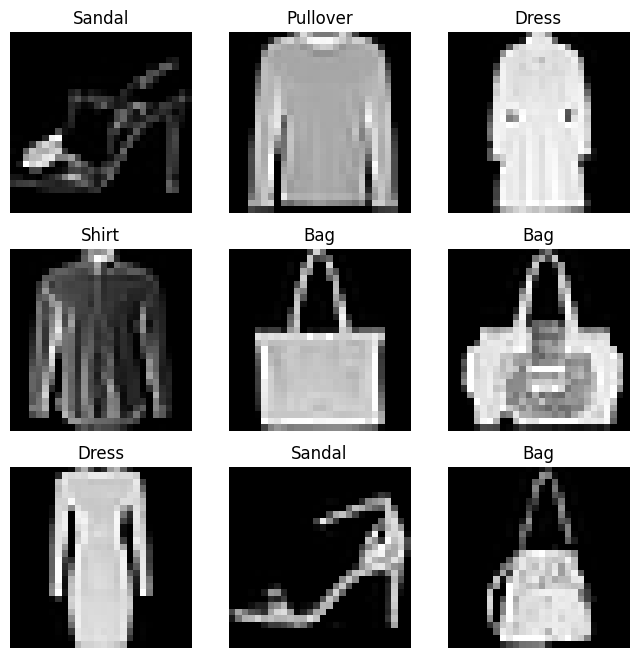

In [46]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  img, label = training_data[sample_idx]
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Creating a custom dataset

In [47]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform
  
  def __len__(self):
    return len(self.img_labels)
  
  def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    image = decode_image(img_path)
    label = self.img_labels.iloc[idx, 1]
    if self.transform:
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(label)
    return image, label

Preparing data for training with DataLoaders

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


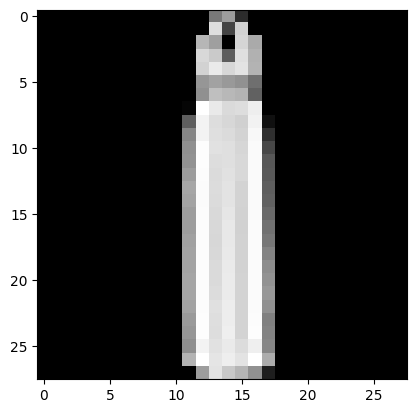

Label: 3


In [48]:
from torch.utils.data import Dataset

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

train_features, train_labels = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0]

plt.imshow(img, cmap="gray")
plt.show()

print(f"Label: {label}")

## 4. Transforms

In [49]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2

ds = datasets.FashionMNIST(
  root="./data",
  train=True,
  download=True,
  transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
  target_transform=v2.Lambda(
    lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
  )
)

## 5. Build the Neural Network

In [50]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [51]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available else "cpu"
print(f"Using {device} device")

Using mps device


In [64]:
class NeuralNetwork2(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(28*28, 512),
      nn.ReLU(),
      nn.Linear(512, 512),
      nn.ReLU(),
      nn.Linear(512, 10),
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

In [65]:
model = NeuralNetwork2().to(device)
print(model)

NeuralNetwork2(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [66]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
print(f"Model output: \n {logits}")
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Model output: 
 tensor([[-0.0580,  0.0426, -0.1028, -0.0655,  0.0090,  0.1190,  0.0643,  0.0628,
          0.0491,  0.0467]], device='mps:0', grad_fn=<LinearBackward0>)
Predicted class: tensor([5], device='mps:0')


### Model layers

In [67]:
input_image = torch.rand(3, 28, 28)
print(input_image.size())

torch.Size([3, 28, 28])


In [68]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


In [69]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [70]:
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[-0.2905, -0.3798, -0.0259, -0.3425, -0.4670, -0.3098, -0.4533,  0.3633,
         -0.3471,  0.3328,  0.0648, -0.0446,  0.1832, -0.1747,  0.3263, -0.2805,
         -0.2671,  0.0111,  0.5597,  0.8861],
        [-0.1451, -0.1014,  0.0869, -0.2407, -0.4598, -0.0434, -0.6781,  0.1328,
         -0.1262,  0.0969,  0.3245, -0.2799,  0.2563,  0.0367,  0.5616,  0.0658,
         -0.1144,  0.4795,  0.5820,  0.3383],
        [-0.1051, -0.4818,  0.0610,  0.1729, -0.2916, -0.0333, -0.5148,  0.1543,
         -0.3083,  0.3935,  0.1858,  0.1321,  0.4321, -0.1538,  0.2627, -0.2251,
         -0.7791,  0.0835,  0.1336,  0.0635]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3633, 0.0000,
         0.3328, 0.0648, 0.0000, 0.1832, 0.0000, 0.3263, 0.0000, 0.0000, 0.0111,
         0.5597, 0.8861],
        [0.0000, 0.0000, 0.0869, 0.0000, 0.0000, 0.0000, 0.0000, 0.1328, 0.0000,
         0.0969, 0.3245, 0.0000, 0.2563, 0.0367, 0.56

In [71]:
seq_modules = nn.Sequential(
  flatten,
  layer1,
  nn.ReLU(),
  nn.Linear(20, 20)
)

input_image = torch.rand(3, 28, 28)
logits = seq_modules(input_image)

In [72]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)

Model parameters

In [73]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
  print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork2(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0181,  0.0069,  0.0047,  ...,  0.0234, -0.0068, -0.0228],
        [ 0.0273,  0.0011,  0.0091,  ...,  0.0045, -0.0275, -0.0189]],
       device='mps:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([ 0.0260, -0.0253], device='mps:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[ 0.0259,  0.0068,  0.0383,  ..., -0.0202,  0.0170,  0.0293],
        [ 0.0395, -0.0211, -0.0227,  ...,  0.0063,  0.0182, -0.0170]],
       device='mps:0', grad_fn=<Slic

## 6. Autograd

In [74]:
x = torch.ones(5) # input tensor
y = torch.zeros(3) # expected tensor
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [76]:
print(f" x = {x} \n y = {y} \n w = {w} \n b = {b} \n z = {z} \n loss = {loss}")

 x = tensor([1., 1., 1., 1., 1.]) 
 y = tensor([0., 0., 0.]) 
 w = tensor([[ 0.6606, -0.9018,  0.7333],
        [-1.5276, -0.8334,  0.6365],
        [ 0.9271, -0.4377, -1.7357],
        [-0.1837,  0.7934,  0.1857],
        [-0.3293, -0.3180, -1.3181]], requires_grad=True) 
 b = tensor([1.4100, 2.3873, 1.0180], requires_grad=True) 
 z = tensor([ 0.9571,  0.6898, -0.4803], grad_fn=<AddBackward0>) 
 loss = 0.9533527493476868


In [77]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x12091a9b0>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x12091a4d0>


### Computing gradient

In [78]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.2408, 0.2220, 0.1274],
        [0.2408, 0.2220, 0.1274],
        [0.2408, 0.2220, 0.1274],
        [0.2408, 0.2220, 0.1274],
        [0.2408, 0.2220, 0.1274]])
tensor([0.2408, 0.2220, 0.1274])


Disabling gradient tracking when it is not required. For example when we want to predict some value and only need forward computations through network

In [79]:
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w)+b
print(z.requires_grad)

True
False


In [80]:
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

False


### Jacobian Products

In [81]:
inp = torch.eye(4, 5, requires_grad=True)
out = (inp+1).pow(2).t()

out.backward(torch.ones_like(out), retain_graph=True)
print(f"First call \n{inp.grad}")

out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nSecond call\n{inp.grad}")

inp.grad.zero_()
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nCall after zeroing gradients\n{inp.grad}")

First call 
tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])

Second call
tensor([[8., 4., 4., 4., 4.],
        [4., 8., 4., 4., 4.],
        [4., 4., 8., 4., 4.],
        [4., 4., 4., 8., 4.]])

Call after zeroing gradients
tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])


## 7. Optimization

Optimizing Model Parameters

In [82]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

Following are the hyperparameters for training our model.

In [83]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

Loss function

In [84]:
loss_fn = nn.CrossEntropyLoss()

Optimizer

In [85]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

### Training loop

In [88]:
def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)

  model.train()
  for batch, (X, y) in enumerate(dataloader):
    pred = model(X)
    loss = loss_fn(pred, y)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * batch_size + len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")
    
def test_loop(dataloader, model, loss_fn):
  model.eval()
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  
  test_loss /= num_batches
  correct /= size

  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


Run training loop

In [89]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.294563 [   64/60000]
loss: 2.289614 [ 6464/60000]
loss: 2.274482 [12864/60000]
loss: 2.271081 [19264/60000]
loss: 2.251409 [25664/60000]
loss: 2.223596 [32064/60000]
loss: 2.233352 [38464/60000]
loss: 2.202571 [44864/60000]
loss: 2.189101 [51264/60000]
loss: 2.178519 [57664/60000]
Test Error: 
 Accuracy: 43.8%, Avg loss: 2.162432 

Epoch 2
-------------------------------
loss: 2.165444 [   64/60000]
loss: 2.166185 [ 6464/60000]
loss: 2.112721 [12864/60000]
loss: 2.133224 [19264/60000]
loss: 2.087818 [25664/60000]
loss: 2.027328 [32064/60000]
loss: 2.063804 [38464/60000]
loss: 1.986836 [44864/60000]
loss: 1.983662 [51264/60000]
loss: 1.943388 [57664/60000]
Test Error: 
 Accuracy: 58.9%, Avg loss: 1.922926 

Epoch 3
-------------------------------
loss: 1.943436 [   64/60000]
loss: 1.932692 [ 6464/60000]
loss: 1.815194 [12864/60000]
loss: 1.862086 [19264/60000]
loss: 1.764636 [25664/60000]
loss: 1.704818 [32064/60000]
loss: 1.739024 [38464/

## 8. Save & Load Model

Loading a model

In [94]:
import torchvision.models as models
model = models.vgg16(weights='IMAGENET1K_V1')
torch.save(model.state_dict(), './nn_models/model_weights.pth')

In [95]:
model = models.vgg16() # we do not specify ``weights``, i.e. create untrained model
model.load_state_dict(torch.load('./nn_models/model_weights.pth', weights_only=True))
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [96]:
torch.save(model, './nn_models/model.pth')

In [97]:
model = torch.load('./nn_models/model.pth', weights_only=False)